## 1. Setup — Install & Import Libraries

In [1]:

!pip install -q pandas numpy matplotlib seaborn plotly scikit-learn statsmodels ipywidgets fpdf2 openpyxl anthropic


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.0/337.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 38.1 MB/s eta 0:00:00


In [2]:
import io
import os
import getpass
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print(" Libraries loaded.")


✅ Libraries loaded.


## 2. CSV / Excel Upload



In [4]:
def generate_sample_data(n_days=730):
    """Creates a realistic synthetic daily sales dataset as a fallback / demo dataset."""
    rng = pd.date_range(end=pd.Timestamp.today().normalize(), periods=n_days, freq="D")
    np.random.seed(42)
    trend = np.linspace(500, 1500, n_days)
    weekly_seasonality = 150 * np.sin(2 * np.pi * rng.dayofweek / 7)
    yearly_seasonality = 300 * np.sin(2 * np.pi * rng.dayofyear / 365)
    noise = np.random.normal(0, 80, n_days)
    sales = trend + weekly_seasonality + yearly_seasonality + noise
    sales = np.clip(sales, 50, None)

    regions = np.random.choice(["North", "South", "East", "West"], n_days, p=[0.3, 0.25, 0.25, 0.2])
    categories = np.random.choice(["Electronics", "Clothing", "Home & Garden", "Sports", "Books"], n_days)
    units = (sales / np.random.uniform(15, 25, n_days)).astype(int)

    df = pd.DataFrame({
        "Date": rng,
        "Region": regions,
        "Category": categories,
        "Units_Sold": units,
        "Sales": sales.round(2),
        "Profit": (sales * np.random.uniform(0.1, 0.3, n_days)).round(2),
    })

    df.loc[df.sample(frac=0.02, random_state=1).index, "Sales"] = np.nan
    df.loc[df.sample(frac=0.01, random_state=2).index, "Region"] = None
    dup_rows = df.sample(frac=0.01, random_state=3)
    df = pd.concat([df, dup_rows], ignore_index=True)
    return df


def load_uploaded_file():
    """Handles the Colab file-upload widget for CSV/Excel files."""
    try:
        from google.colab import files
        print(" Choose a CSV or Excel file to upload (Cancel to use sample data instead)...")
        uploaded = files.upload()
    except Exception:
        uploaded = {}

    if not uploaded:
        print("ℹ No file uploaded — generating a sample sales dataset instead.")
        return generate_sample_data()

    filename = list(uploaded.keys())[0]
    content = uploaded[filename]

    if filename.lower().endswith((".xlsx", ".xls")):
        df = pd.read_excel(io.BytesIO(content))
    else:
        df = pd.read_csv(io.BytesIO(content))

    print(f" Loaded '{filename}' — {df.shape[0]} rows x {df.shape[1]} columns.")
    return df


raw_df = load_uploaded_file()
raw_df.head(10)


📤 Choose a CSV or Excel file to upload (Cancel to use sample data instead)...


Saving train.csv to train.csv
✅ Loaded 'train.csv' — 9800 rows x 18 columns.


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


## 3. Data Cleaning



In [5]:
def clean_data(df):
    df = df.copy()
    report = []


    original_cols = list(df.columns)
    df.columns = [str(c).strip().replace(" ", "_") for c in df.columns]
    report.append(f"Standardized {len(original_cols)} column names.")


    date_col = None
    for c in df.columns:
        if "date" in c.lower() or "time" in c.lower():
            try:
                df[c] = pd.to_datetime(df[c], errors="coerce")
                if df[c].notna().sum() > 0:
                    date_col = c
                    break
            except Exception:
                pass
    if date_col:
        report.append(f"Parsed '{date_col}' as a datetime column.")


    before = len(df)
    df = df.drop_duplicates()
    removed = before - len(df)
    if removed:
        report.append(f"Removed {removed} duplicate rows.")


    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = df.select_dtypes(include="object").columns.tolist()

    for c in numeric_cols:
        n_missing = df[c].isna().sum()
        if n_missing:
            df[c] = df[c].fillna(df[c].median())
            report.append(f"Filled {n_missing} missing values in '{c}' with the median.")

    for c in categorical_cols:
        n_missing = df[c].isna().sum()
        if n_missing:
            mode_val = df[c].mode(dropna=True)
            fill_val = mode_val.iloc[0] if not mode_val.empty else "Unknown"
            df[c] = df[c].fillna(fill_val)
            report.append(f"Filled {n_missing} missing values in '{c}' with '{fill_val}'.")


    if date_col:
        df = df.sort_values(date_col).reset_index(drop=True)

    return df, date_col, report


clean_df, date_col, cleaning_report = clean_data(raw_df)

print("🧹 Data Cleaning Summary")
print("-" * 40)
for line in cleaning_report:
    print("•", line)
print("-" * 40)
print(f"Final shape: {clean_df.shape[0]} rows x {clean_df.shape[1]} columns")

clean_df.head(10)


🧹 Data Cleaning Summary
----------------------------------------
• Standardized 18 column names.
• Parsed 'Order_Date' as a datetime column.
• Filled 11 missing values in 'Postal_Code' with the median.
----------------------------------------
Final shape: 9800 rows x 18 columns


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales
0,541,CA-2015-140795,2015-01-02,03/02/2015,First Class,BD-11500,Bradley Drucker,Consumer,United States,Green Bay,Wisconsin,54302.0,Central,TEC-AC-10001432,Technology,Accessories,Enermax Aurora Lite Keyboard,468.900
1,6548,CA-2015-113880,2015-01-03,05/03/2015,Standard Class,VF-21715,Vicky Freymann,Home Office,United States,Elmhurst,Illinois,60126.0,Central,FUR-CH-10000863,Furniture,Chairs,Novimex Swivel Fabric Task Chair,634.116
2,158,CA-2015-104269,2015-01-03,06/03/2015,Second Class,DB-13060,Dave Brooks,Consumer,United States,Seattle,Washington,98115.0,West,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,457.568
3,7948,CA-2015-131009,2015-01-03,05/03/2015,Standard Class,SC-20380,Shahid Collister,Consumer,United States,El Paso,Texas,79907.0,Central,OFF-FA-10004395,Office Supplies,Fasteners,Plymouth Boxed Rubber Bands by Plymouth,18.840
4,7949,CA-2015-131009,2015-01-03,05/03/2015,Standard Class,SC-20380,Shahid Collister,Consumer,United States,El Paso,Texas,79907.0,Central,FUR-CH-10001270,Furniture,Chairs,Harbour Creations Steel Folding Chair,362.250
5,7950,CA-2015-131009,2015-01-03,05/03/2015,Standard Class,SC-20380,Shahid Collister,Consumer,United States,El Paso,Texas,79907.0,Central,FUR-FU-10001095,Furniture,Furnishings,DAX Black Cherry Wood-Tone Poster Frame,63.552
6,8311,CA-2015-168312,2015-01-03,07/03/2015,Standard Class,GW-14605,Giulietta Weimer,Consumer,United States,Houston,Texas,77036.0,Central,FUR-TA-10001866,Furniture,Tables,Bevis Round Conference Room Tables and Bases,376.509
7,7951,CA-2015-131009,2015-01-03,05/03/2015,Standard Class,SC-20380,Shahid Collister,Consumer,United States,El Paso,Texas,79907.0,Central,OFF-ST-10001469,Office Supplies,Storage,Fellowes Bankers Box Recycled Super Stor/Drawer,129.552
8,8310,CA-2015-168312,2015-01-03,07/03/2015,Standard Class,GW-14605,Giulietta Weimer,Consumer,United States,Houston,Texas,77036.0,Central,OFF-ST-10003692,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,137.352
9,5714,US-2015-143707,2015-01-03,05/03/2015,Standard Class,HR-14770,Hallie Redmond,Home Office,United States,New York City,New York,10035.0,East,TEC-PH-10003655,Technology,Phones,Sannysis Cute Owl Design Soft Skin Case Cover ...,5.940


In [6]:

def detect_sales_column(df):
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    if not numeric_cols:
        raise ValueError("No numeric columns found — cannot analyze sales.")
    priority_keywords = ["sales", "revenue", "amount", "total", "income"]
    for kw in priority_keywords:
        for c in numeric_cols:
            if kw in c.lower():
                return c
    return numeric_cols[0]


sales_col = detect_sales_column(clean_df)
print(f" Detected sales/revenue column: '{sales_col}'")
if date_col:
    print(f" Detected date column: '{date_col}'")
else:
    print(" No date column detected — trend/prediction sections will use row order instead.")


📌 Detected sales/revenue column: 'Sales'
📌 Detected date column: 'Order_Date'


## 4. Automated Charts



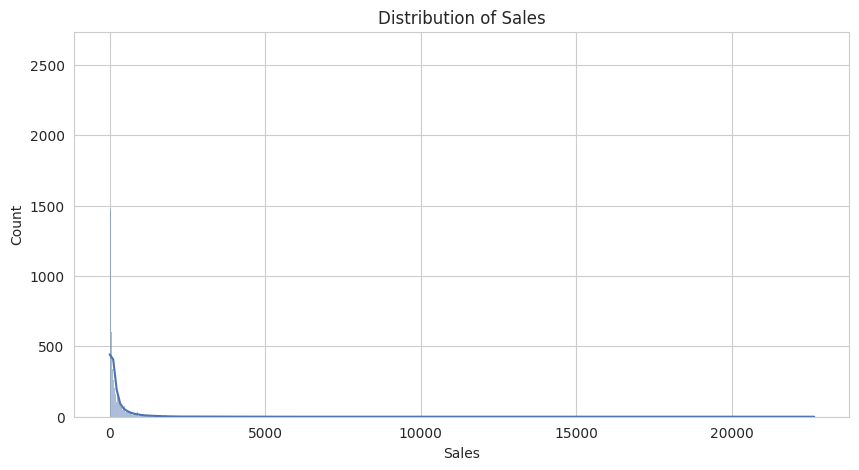

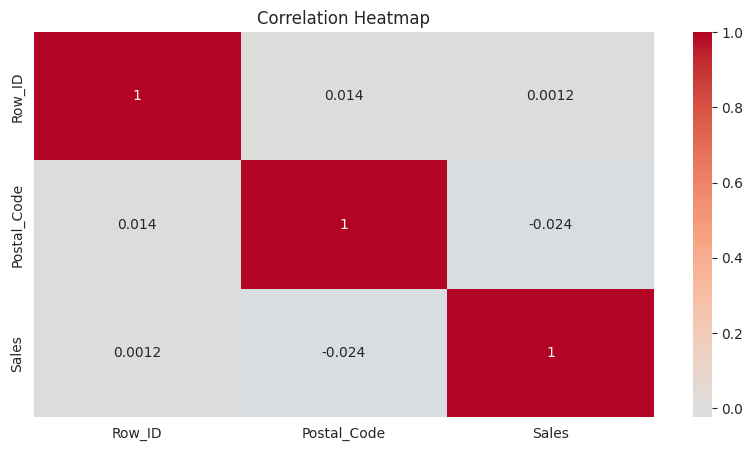

In [7]:
numeric_cols = clean_df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in clean_df.select_dtypes(include="object").columns if clean_df[c].nunique() <= 20]


if date_col:
    daily = clean_df.groupby(date_col)[sales_col].sum().reset_index()
    fig = px.line(daily, x=date_col, y=sales_col, title=f"{sales_col} Over Time")
    fig.show()


plt.figure()
sns.histplot(clean_df[sales_col], kde=True, color="#4C72B0")
plt.title(f"Distribution of {sales_col}")
plt.xlabel(sales_col)
plt.show()


for c in categorical_cols[:3]:
    grouped = clean_df.groupby(c)[sales_col].sum().sort_values(ascending=False).reset_index()
    fig = px.bar(grouped, x=c, y=sales_col, title=f"{sales_col} by {c}", color=c)
    fig.show()


if len(numeric_cols) > 1:
    plt.figure()
    sns.heatmap(clean_df[numeric_cols].corr(), annot=True, cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap")
    plt.show()


## 5. Trend Analysis



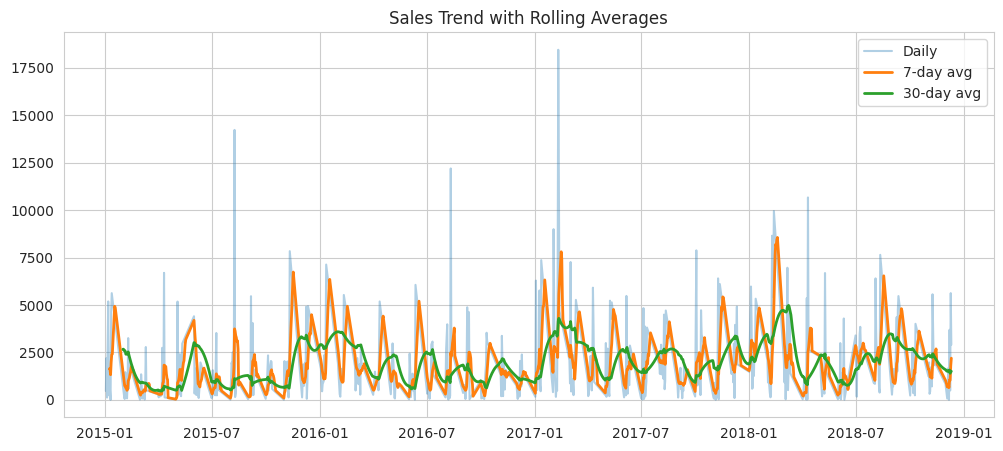

📈 Growth rate (first 30 days avg -> last 30 days avg): -43.65%


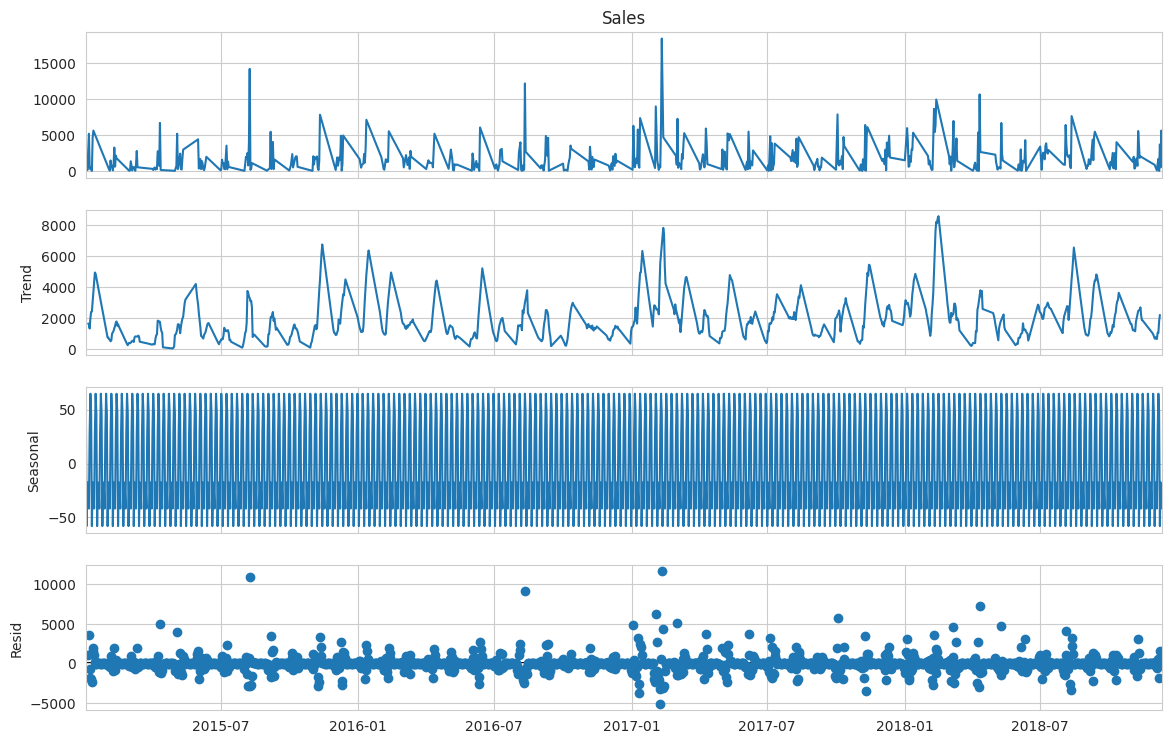

In [8]:
if date_col:
    ts = clean_df.groupby(date_col)[sales_col].sum().asfreq("D").interpolate()

    rolling_7 = ts.rolling(7).mean()
    rolling_30 = ts.rolling(30).mean()

    plt.figure(figsize=(12, 5))
    plt.plot(ts.index, ts.values, label="Daily", alpha=0.35)
    plt.plot(rolling_7.index, rolling_7.values, label="7-day avg", linewidth=2)
    plt.plot(rolling_30.index, rolling_30.values, label="30-day avg", linewidth=2)
    plt.title(f"{sales_col} Trend with Rolling Averages")
    plt.legend()
    plt.show()


    first_period = ts.iloc[: min(30, len(ts))].mean()
    last_period = ts.iloc[-min(30, len(ts)):].mean()
    growth_pct = ((last_period - first_period) / first_period) * 100 if first_period else 0
    print(f"📈 Growth rate (first {min(30,len(ts))} days avg -> last {min(30,len(ts))} days avg): {growth_pct:+.2f}%")


    if len(ts) >= 60:
        from statsmodels.tsa.seasonal import seasonal_decompose
        decomposition = seasonal_decompose(ts, model="additive", period=7)
        fig = decomposition.plot()
        fig.set_size_inches(12, 8)
        plt.show()
    else:
        print("ℹ Not enough data points for seasonal decomposition (need 60+ days).")
else:
    ts = clean_df[sales_col].reset_index(drop=True)
    rolling_7 = ts.rolling(7).mean()
    plt.figure()
    plt.plot(ts.values, label="Value", alpha=0.4)
    plt.plot(rolling_7.values, label="7-row rolling avg", linewidth=2)
    plt.title(f"{sales_col} Trend (row order, no date column found)")
    plt.legend()
    plt.show()
    growth_pct = None


## 6. Sales Prediction


🤖 Model comparison (lower MAE / higher R² is better):
  • Linear Regression: MAE=1311.05, R²=-0.084  ⭐ (selected)
  • Random Forest: MAE=1556.11, R²=-0.913


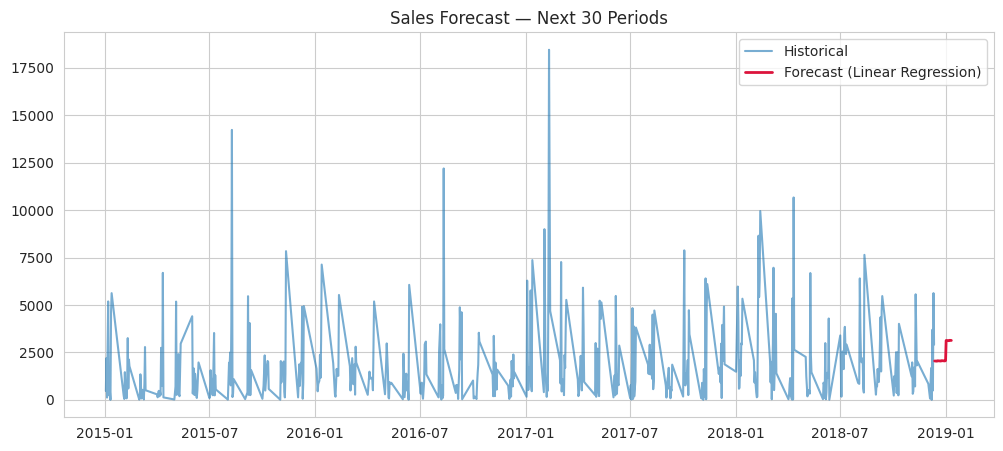

,period,forecast_Sales
0,2018-12-12,2049.46
1,2018-12-13,2047.07
2,2018-12-14,2044.68
3,2018-12-15,2042.30
4,2018-12-16,2039.91
5,2018-12-17,2060.14
6,2018-12-18,2057.75
7,2018-12-19,2055.36
8,2018-12-20,2052.98
9,2018-12-21,2050.59


In [9]:
FORECAST_DAYS = 30

def build_forecast(ts, forecast_days=FORECAST_DAYS):
    series = ts.dropna()
    df_model = pd.DataFrame({"y": series.values})
    df_model["t"] = np.arange(len(df_model))
    df_model["dow"] = series.index.dayofweek if hasattr(series.index, "dayofweek") else 0
    df_model["month"] = series.index.month if hasattr(series.index, "month") else 0

    split = int(len(df_model) * 0.85)
    train, test = df_model.iloc[:split], df_model.iloc[split:]
    features = ["t", "dow", "month"]

    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    }

    results = {}
    for name, model in models.items():
        model.fit(train[features], train["y"])
        preds = model.predict(test[features]) if len(test) else np.array([])
        mae = mean_absolute_error(test["y"], preds) if len(test) else np.nan
        r2 = r2_score(test["y"], preds) if len(test) > 1 else np.nan
        results[name] = {"model": model, "mae": mae, "r2": r2}

    best_name = min(results, key=lambda k: (results[k]["mae"] if not np.isnan(results[k]["mae"]) else np.inf))
    best_model = results[best_name]["model"]


    best_model.fit(df_model[features], df_model["y"])
    future_t = np.arange(len(df_model), len(df_model) + forecast_days)
    if hasattr(series.index, "dayofweek"):
        future_dates = pd.date_range(series.index[-1] + pd.Timedelta(days=1), periods=forecast_days)
        future_dow = future_dates.dayofweek
        future_month = future_dates.month
    else:
        future_dates = np.arange(forecast_days)
        future_dow = np.zeros(forecast_days)
        future_month = np.zeros(forecast_days)

    future_X = pd.DataFrame({"t": future_t, "dow": future_dow, "month": future_month})
    forecast_values = best_model.predict(future_X)

    return best_name, results, future_dates, forecast_values


best_name, model_results, future_dates, forecast_values = build_forecast(ts)

print(" Model comparison (lower MAE / higher R² is better):")
for name, r in model_results.items():
    mae_str = f"{r['mae']:.2f}" if not np.isnan(r['mae']) else "n/a"
    r2_str = f"{r['r2']:.3f}" if not np.isnan(r['r2']) else "n/a"
    marker = "   (selected)" if name == best_name else ""
    print(f"  • {name}: MAE={mae_str}, R²={r2_str}{marker}")

plt.figure(figsize=(12, 5))
plt.plot(ts.index, ts.values, label="Historical", alpha=0.6)
plt.plot(future_dates, forecast_values, label=f"Forecast ({best_name})", linewidth=2, color="crimson")
plt.title(f"{sales_col} Forecast — Next {FORECAST_DAYS} Periods")
plt.legend()
plt.show()

forecast_df = pd.DataFrame({"period": future_dates, "forecast_" + sales_col: forecast_values.round(2)})
forecast_df.head(10)


## 7. AI-Generated Insights



In [10]:
def compute_insight_facts(df, ts, sales_col, growth_pct, forecast_values, categorical_cols):
    facts = {}
    facts["total"] = df[sales_col].sum()
    facts["average"] = df[sales_col].mean()
    facts["max"] = df[sales_col].max()
    facts["min"] = df[sales_col].min()
    facts["growth_pct"] = growth_pct
    facts["forecast_avg"] = float(np.mean(forecast_values))
    facts["forecast_vs_recent"] = None
    if len(ts) >= 30:
        recent_avg = ts.iloc[-30:].mean()
        facts["forecast_vs_recent"] = ((facts["forecast_avg"] - recent_avg) / recent_avg) * 100 if recent_avg else None

    facts["top_categories"] = {}
    for c in categorical_cols[:2]:
        top = df.groupby(c)[sales_col].sum().idxmax()
        facts["top_categories"][c] = top
    return facts


def generate_rule_based_insights(facts, sales_col):
    lines = []
    lines.append(f"Total {sales_col} across the dataset is {facts['total']:,.0f}, averaging {facts['average']:,.1f} per record.")
    lines.append(f"The single highest value recorded was {facts['max']:,.0f}, and the lowest was {facts['min']:,.0f}.")
    if facts["growth_pct"] is not None:
        direction = "grew" if facts["growth_pct"] >= 0 else "declined"
        lines.append(f"{sales_col} {direction} by {abs(facts['growth_pct']):.1f}% comparing the earliest to the most recent period.")
    if facts["forecast_vs_recent"] is not None:
        direction = "higher" if facts["forecast_vs_recent"] >= 0 else "lower"
        lines.append(f"The forecast for the next period is {abs(facts['forecast_vs_recent']):.1f}% {direction} than the recent 30-period average.")
    for c, top in facts["top_categories"].items():
        lines.append(f"'{top}' is the top-performing {c} by total {sales_col}.")
    return lines


insight_facts = compute_insight_facts(clean_df, ts, sales_col, growth_pct if date_col else None, forecast_values, categorical_cols)
insight_bullets = generate_rule_based_insights(insight_facts, sales_col)

print(" AI-Generated Insights (rule-based)")
print("-" * 40)
for b in insight_bullets:
    print("•", b)


💡 AI-Generated Insights (rule-based)
----------------------------------------
• Total Sales across the dataset is 2,261,537, averaging 230.8 per record.
• The single highest value recorded was 22,638, and the lowest was 0.
• Sales declined by 43.6% comparing the earliest to the most recent period.
• The forecast for the next period is 60.3% higher than the recent 30-period average.
• 'Standard Class' is the top-performing Ship_Mode by total Sales.
• 'Consumer' is the top-performing Segment by total Sales.


In [11]:

USE_LLM = False
anthropic_api_key = None

use_llm_input = input("Use the Anthropic API to generate a richer narrative? (y/n): ").strip().lower()
if use_llm_input == "y":
    anthropic_api_key = getpass.getpass("Paste your Anthropic API key (input hidden): ").strip()
    USE_LLM = bool(anthropic_api_key)

llm_narrative = None
if USE_LLM:
    try:
        import anthropic
        client = anthropic.Anthropic(api_key=anthropic_api_key)
        prompt = (
            "You are a business analyst. Turn these computed facts and bullet points into a short, "
            "polished executive summary (3-5 sentences, no bullet points, confident and concise tone). "
            f"Facts: {insight_facts}\nBullet points: {insight_bullets}"
        )
        response = client.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=400,
            messages=[{"role": "user", "content": prompt}],
        )
        llm_narrative = "".join(block.text for block in response.content if block.type == "text")
        print(" AI Executive Summary (Claude):\n")
        print(llm_narrative)
    except Exception as e:
        print(f" Could not reach the Anthropic API ({e}). Falling back to rule-based insights only.")
else:
    print("ℹ Skipping LLM narrative — using rule-based insights above.")


Use the Anthropic API to generate a richer narrative? (y/n): y
Paste your Anthropic API key (input hidden): ··········
⚠️ Could not reach the Anthropic API (Error code: 401 - {'type': 'error', 'error': {'type': 'authentication_error', 'message': 'invalid x-api-key'}, 'request_id': 'req_011CeBzf5BQHLXZyxfiJTUga'}). Falling back to rule-based insights only.


## 8. Upgrade: Natural Language Queries



In [12]:
def rule_based_query(question, df, sales_col, date_col):
    q = question.lower()

    if "total" in q or "sum" in q:
        return f"Total {sales_col}: {df[sales_col].sum():,.2f}"
    if "average" in q or "mean" in q:
        return f"Average {sales_col}: {df[sales_col].mean():,.2f}"
    if "max" in q or "highest" in q:
        return f"Maximum {sales_col}: {df[sales_col].max():,.2f}"
    if "min" in q or "lowest" in q:
        return f"Minimum {sales_col}: {df[sales_col].min():,.2f}"
    if "top" in q:
        for c in categorical_cols:
            if c.lower() in q:
                grouped = df.groupby(c)[sales_col].sum().sort_values(ascending=False)
                return f"Top {c} by {sales_col}:\n{grouped.head(5).to_string()}"
    if "trend" in q or "growth" in q:
        if growth_pct is not None:
            return f"{sales_col} growth (first vs last period): {growth_pct:+.2f}%"
    if "forecast" in q or "predict" in q:
        return f"Forecast average for next {FORECAST_DAYS} periods: {np.mean(forecast_values):,.2f}"
    return None


def llm_query(question, df):
    if not USE_LLM:
        return None
    try:
        import anthropic
        client = anthropic.Anthropic(api_key=anthropic_api_key)
        columns_info = ", ".join(f"{c} ({df[c].dtype})" for c in df.columns)
        prompt = (
            "You are a Python data analyst. Given a pandas DataFrame called `df` with these columns: "
            f"{columns_info}. Write ONE single line of pandas code (no imports, no explanation, no "
            "markdown fences, must assign the final result to a variable named `result`) that answers "
            f"this question: \"{question}\""
        )
        response = client.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=200,
            messages=[{"role": "user", "content": prompt}],
        )
        code_str = "".join(b.text for b in response.content if b.type == "text").strip()
        code_str = code_str.replace("```python", "").replace("```", "").strip()

        forbidden = ["import", "open(", "exec(", "eval(", "__", "os.", "sys.", "subprocess"]
        if any(f in code_str for f in forbidden):
            return " Generated code failed safety check — try rephrasing your question."
        local_vars = {"df": df, "pd": pd, "np": np}
        exec(code_str, {}, local_vars)
        return f"(Claude-generated) {code_str}\n=> {local_vars.get('result')}"
    except Exception as e:
        return f" LLM query failed: {e}"


def ask(question):
    answer = rule_based_query(question, clean_df, sales_col, date_col)
    if answer is None:
        answer = llm_query(question, clean_df)
    if answer is None:
        answer = ("Sorry, I couldn't match that to a known pattern. Try asking about total, average, "
                   "max, min, top categories, trend, or forecast — or enable the LLM query in the cell above.")
    print(f" {question}\n💬 {answer}\n")



ask(f"What is the total {sales_col}?")
ask(f"What is the trend?")
ask(f"What is the forecast?")


query_box = widgets.Text(placeholder="Ask a question about your data...", layout=widgets.Layout(width="500px"))
query_button = widgets.Button(description="Ask", button_style="primary")
query_output = widgets.Output()

def on_query_click(b):
    with query_output:
        clear_output()
        if query_box.value.strip():
            ask(query_box.value.strip())

query_button.on_click(on_query_click)
display(widgets.HBox([query_box, query_button]), query_output)


❓ What is the total Sales?
💬 Total Sales: 2,261,536.78

❓ What is the trend?
💬 Sales growth (first vs last period): -43.65%

❓ What is the forecast?
💬 Forecast average for next 30 periods: 2,412.11



Output()

## 9. Upgrade: Interactive Dashboard



In [14]:
metric_dropdown = widgets.Dropdown(options=numeric_cols, value=sales_col, description="Metric:")
chart_dropdown = widgets.Dropdown(options=["Line (over time)", "Bar (by category)", "Histogram", "Box plot"], description="Chart:")
category_dropdown = widgets.Dropdown(options=["(none)"] + categorical_cols, description="Group by:")
dashboard_output = widgets.Output()

def render_dashboard(*args):
    with dashboard_output:
        clear_output(wait=True)
        metric = metric_dropdown.value
        chart = chart_dropdown.value
        group = category_dropdown.value

        plt.figure(figsize=(9, 5))

        if chart == "Line (over time)":
            if date_col:
                data = clean_df.groupby(date_col)[metric].sum()
                plt.plot(data.index, data.values, color="#4C72B0")
                plt.title(f"{metric} Over Time")
                plt.xticks(rotation=45)
            else:
                plt.close()
                print("No date column detected in this dataset, so a time-based line chart isn't available. Try another chart type.")
                return

        elif chart == "Bar (by category)":
            if group != "(none)":
                data = clean_df.groupby(group)[metric].sum().sort_values(ascending=False)
                sns.barplot(x=data.index, y=data.values, hue=data.index, palette="viridis", legend=False)
                plt.title(f"{metric} by {group}")
                plt.xticks(rotation=45)
            else:
                plt.close()
                print("Pick a category in 'Group by' to see a bar chart.")
                return

        elif chart == "Histogram":
            if group != "(none)":
                for val in clean_df[group].unique():
                    sns.histplot(clean_df[clean_df[group] == val][metric], label=str(val), kde=True, alpha=0.5)
                plt.legend(title=group)
            else:
                sns.histplot(clean_df[metric], kde=True, color="#4C72B0")
            plt.title(f"Distribution of {metric}")

        elif chart == "Box plot":
            if group != "(none)":
                sns.boxplot(data=clean_df, x=group, y=metric, hue=group, palette="Set2", legend=False)
                plt.xticks(rotation=45)
                plt.title(f"{metric} Spread by {group}")
            else:
                sns.boxplot(y=clean_df[metric], color="#4C72B0")
                plt.title(f"{metric} Spread")

        plt.tight_layout()
        plt.show()


for w in (metric_dropdown, chart_dropdown, category_dropdown):
    w.observe(render_dashboard, names="value")

dashboard_controls = widgets.HBox([metric_dropdown, chart_dropdown, category_dropdown])
display(dashboard_controls, dashboard_output)
render_dashboard()

Output()

## 10. Upgrade: PDF Report Generation



In [15]:
from fpdf import FPDF
import tempfile

def save_chart_images(df, ts, sales_col, categorical_cols, date_col):
    paths = []
    tmp_dir = tempfile.mkdtemp()


    plt.figure(figsize=(8, 4))
    plt.plot(ts.index, ts.values, alpha=0.4, label="Actual")
    plt.plot(ts.rolling(7).mean().index, ts.rolling(7).mean().values, label="7-period avg")
    plt.title(f"{sales_col} Trend")
    plt.legend()
    p1 = os.path.join(tmp_dir, "trend.png")
    plt.savefig(p1, bbox_inches="tight", dpi=150)
    plt.close()
    paths.append(p1)


    plt.figure(figsize=(8, 4))
    plt.plot(ts.index, ts.values, alpha=0.5, label="Historical")
    plt.plot(future_dates, forecast_values, color="crimson", label="Forecast")
    plt.title(f"{sales_col} Forecast")
    plt.legend()
    p2 = os.path.join(tmp_dir, "forecast.png")
    plt.savefig(p2, bbox_inches="tight", dpi=150)
    plt.close()
    paths.append(p2)


    if categorical_cols:
        c = categorical_cols[0]
        grouped = df.groupby(c)[sales_col].sum().sort_values(ascending=False)
        plt.figure(figsize=(8, 4))
        grouped.plot(kind="bar", color="#4C72B0")
        plt.title(f"{sales_col} by {c}")
        plt.ylabel(sales_col)
        p3 = os.path.join(tmp_dir, "category.png")
        plt.savefig(p3, bbox_inches="tight", dpi=150)
        plt.close()
        paths.append(p3)

    return paths


def build_pdf_report(df, sales_col, insight_bullets, llm_narrative, chart_paths, out_path):
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Helvetica", "B", 18)
    pdf.cell(0, 12, "AI Business Analytics Report", ln=True)
    pdf.set_font("Helvetica", "", 10)
    pdf.set_text_color(100, 100, 100)
    pdf.cell(0, 8, f"Generated {pd.Timestamp.today().strftime('%Y-%m-%d')}", ln=True)
    pdf.set_text_color(0, 0, 0)
    pdf.ln(4)

    pdf.set_font("Helvetica", "B", 13)
    pdf.cell(0, 10, "Summary Statistics", ln=True)
    pdf.set_font("Helvetica", "", 11)
    stats = [
        f"Rows analyzed: {len(df):,}",
        f"Total {sales_col}: {df[sales_col].sum():,.2f}",
        f"Average {sales_col}: {df[sales_col].mean():,.2f}",
        f"Max {sales_col}: {df[sales_col].max():,.2f}",
        f"Min {sales_col}: {df[sales_col].min():,.2f}",
    ]
    for s in stats:
        pdf.cell(0, 7, f"- {s}", ln=True)
    pdf.ln(4)

    pdf.set_font("Helvetica", "B", 13)
    pdf.cell(0, 10, "AI-Generated Insights", ln=True)
    pdf.set_font("Helvetica", "", 11)
    if llm_narrative:
        pdf.multi_cell(0, 6, llm_narrative.strip())
        pdf.ln(2)
    for b in insight_bullets:
        pdf.multi_cell(0, 6, f"- {b}")
    pdf.ln(4)

    pdf.set_font("Helvetica", "B", 13)
    pdf.cell(0, 10, "Charts", ln=True)
    for path in chart_paths:
        if pdf.get_y() > 220:
            pdf.add_page()
        pdf.image(path, w=170)
        pdf.ln(4)

    pdf.output(out_path)
    return out_path


chart_paths = save_chart_images(clean_df, ts, sales_col, categorical_cols, date_col)
report_path = "/content/AI_Business_Analytics_Report.pdf" if os.path.isdir("/content") else "AI_Business_Analytics_Report.pdf"
build_pdf_report(clean_df, sales_col, insight_bullets, llm_narrative, chart_paths, report_path)
print(f" PDF report generated: {report_path}")

try:
    from google.colab import files
    files.download(report_path)
except Exception:
    print("(Not running in Colab — open the file manually from the path above.)")


FPDFException: Not enough horizontal space to render a single character